VFT records : 1,044
SpAM records: 1,033
Subjects    : 35
Merged records: 988

Q1 transitions : 875
Q2 word-points : 949
Q3 subjects    : 33

STATISTICAL RESULTS

Q1: Do Hindi speakers retrieve words in semantic clusters?
  Within-Cluster  — Mean: 4623 ms | Median: 4022 ms | N=517
  Between-Cluster — Mean: 4610 ms | Median: 3752 ms | N=358
  Welch t-test    : t = 0.064,  p = 0.9489
  Mann-Whitney U  : U = 94910, p = 0.7402  (one-tailed: within < between)


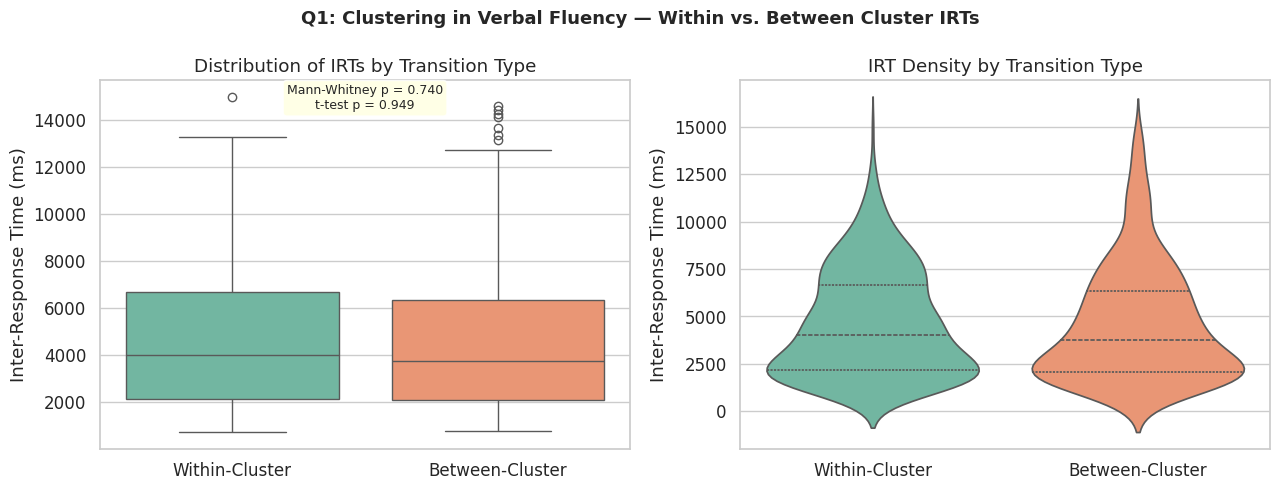


Q2: Do faster retrievals reflect tighter semantic neighbourhoods?
  Pearson  r   = -0.104,  p = 0.0013
  Spearman rho = -0.153,  p = 0.0000


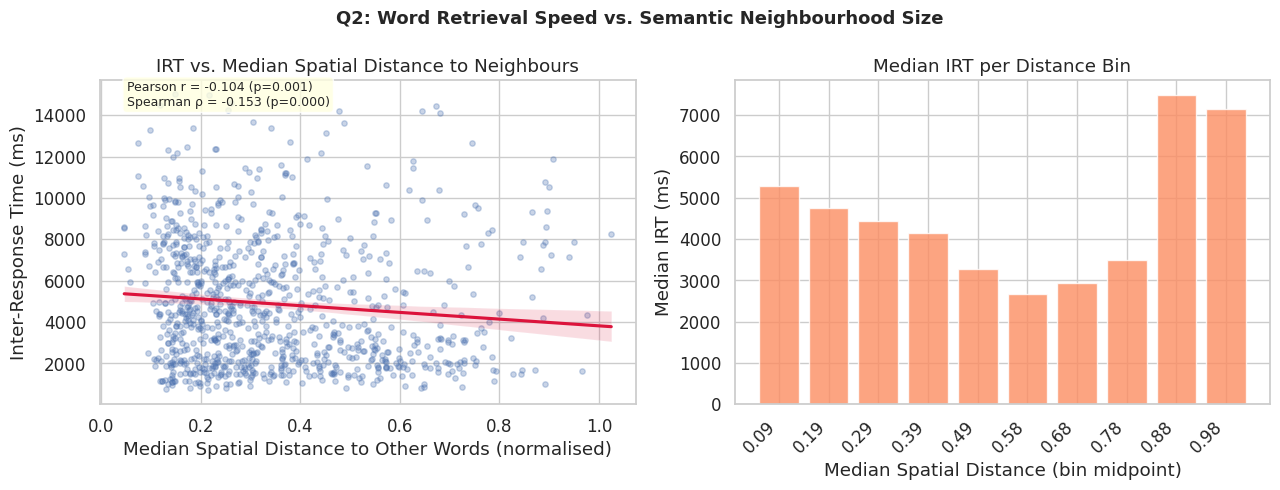


Q3: Does Hindi fluency predict lexical retrieval efficiency?
  Fluency vs Total Words Produced  : Pearson r=-0.159 (p=0.377),  Spearman ρ=-0.212 (p=0.235)
  Fluency vs Mean IRT (ms)         : Pearson r=0.249 (p=0.162),  Spearman ρ=0.189 (p=0.292)
  Fluency vs Mean Cluster Size     : Pearson r=0.039 (p=0.831),  Spearman ρ=0.097 (p=0.591)


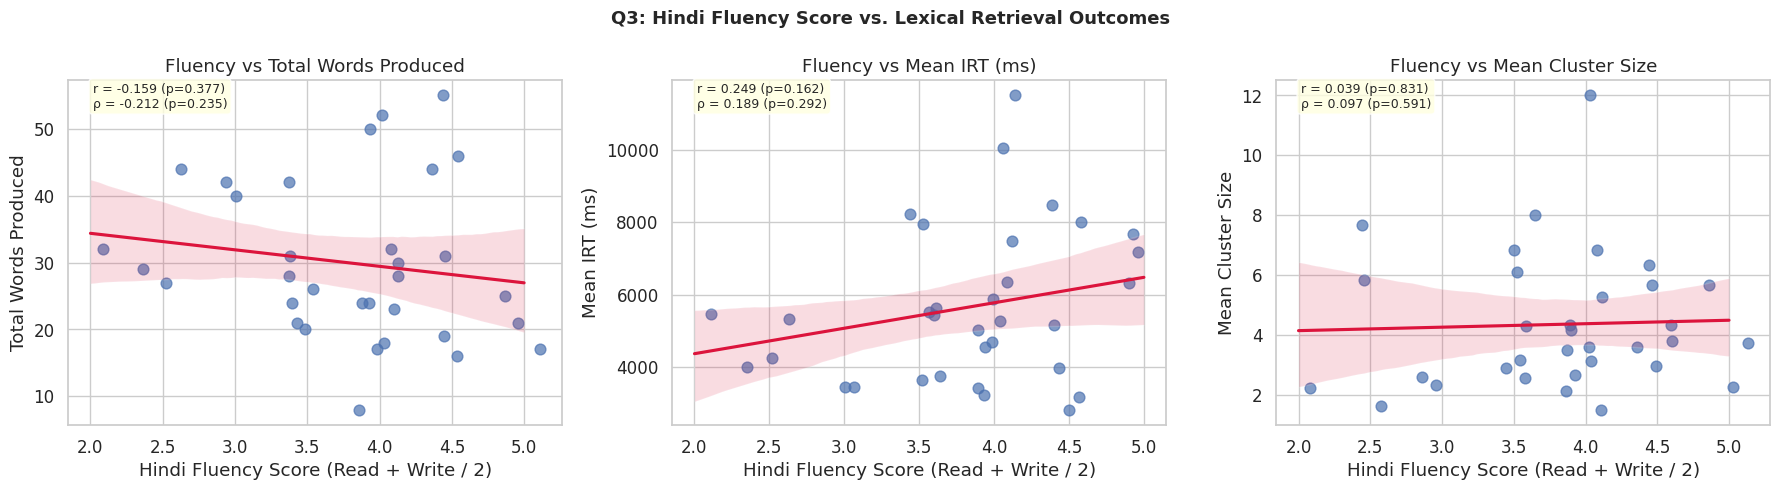


Bonus: Serial-position IRT trajectory


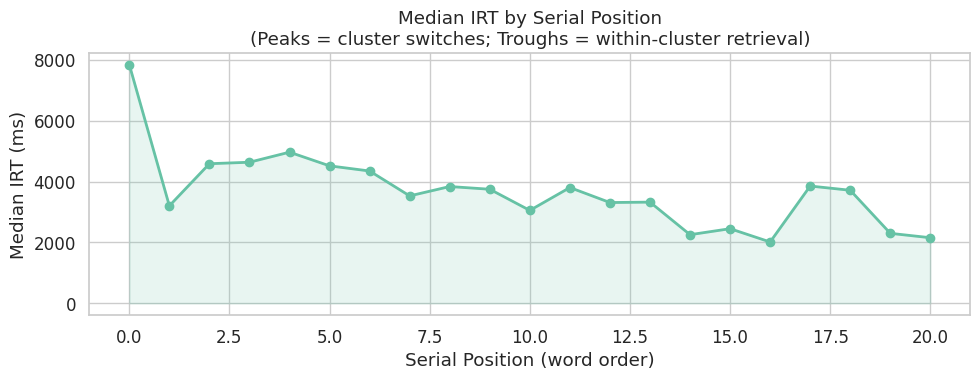


All plots saved.
SUMMARY TABLE
 subject_id  total_words     mean_irt  mean_cluster_size  n_clusters  fluency_score
       3342           21  7938.338095           4.277778    2.000000            3.5
       5157           28  5619.155556           6.833333    2.000000            3.5
      10147           17  7190.023016           5.666667    1.000000            5.0
      10255           50  3243.445556           3.583333    4.666667            4.0
      13498           20  8234.231429           2.555556    2.666667            3.5
      13549           26  5534.253307           2.888889    3.000000            3.5
      20970           31  5175.813333           3.583333    3.333333            4.5
      23853           24  5014.000000           5.277778    2.000000            4.0
      25803           42  3455.402633           2.324074    6.333333            3.0
      31417           24  5887.179167           6.833333    1.333333            4.0
      34350           55  2831.661028       

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering
from scipy.stats import pearsonr, spearmanr, mannwhitneyu, ttest_ind
import warnings
warnings.filterwarnings('ignore')

# CONFIGURATION

DATA_PATH = 'responses (1).json'
IRT_CUTOFF_MS = 15000
CLUSTER_THRESHOLD = 0.25
MIN_WORDS_PER_GROUP = 3
RANDOM_SEED = 42

sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = sns.color_palette("Set2")

# 1. LOAD DATA

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

fluency_data = data.get('fluency-spam', {})

vft_records   = []
spam_records  = []
subject_fluency = {}

# 2. PARSE JSON

for session_id, session in fluency_data.items():
    subject_id = session.get('subject_id', 'Unknown')
    trials     = session.get('data', [])

    fluency_score = np.nan

    for trial in trials:

        if 'response' in trial and isinstance(trial['response'], dict):
            resp = trial['response']
            if 'Hi_Read' in resp and 'Hi_Write' in resp:
                try:
                    fluency_score = (int(resp['Hi_Read']) + int(resp['Hi_Write'])) / 2
                except (ValueError, TypeError):
                    pass

        if trial.get('task') == 'VFT':
            domain = trial.get('domain', '')
            if 'practice' in domain:
                continue
            try:
                responses = json.loads(trial.get('tagged_responses', '[]'))
                irts      = json.loads(trial.get('response_times',   '[]'))
                words     = [r['response'].strip() for r in responses]

                if len(words) != len(irts):
                    print(f"[WARN] Subject {subject_id}, domain {domain}: "
                          f"words/IRTs length mismatch ({len(words)} vs {len(irts)}). "
                          f"Truncating to shorter list.")
                    min_len = min(len(words), len(irts))
                    words, irts = words[:min_len], irts[:min_len]

                for i, (word, irt) in enumerate(zip(words, irts)):

                    try:
                        irt_val = float(irt)
                    except (TypeError, ValueError):
                        continue
                    vft_records.append({
                        'subject_id': subject_id,
                        'domain':     domain,
                        'word':       word,
                        'order':      i,
                        'irt':        irt_val
                    })
            except (json.JSONDecodeError, KeyError):
                continue

        # --- SpAM ---
        if trial.get('task') == 'SpAM':
            domain = trial.get('domain', '')
            if 'practice' in domain:
                continue

            dropped = trial.get('droppedwords', [])


            final_positions = {}
            for drop in dropped:
                word = drop.get('word', '').strip()
                x    = drop.get('x_norm')
                y    = drop.get('y_norm')
                if word and x is not None and y is not None:
                    final_positions[word] = (float(x), float(y))

            for word, (x, y) in final_positions.items():
                spam_records.append({
                    'subject_id': subject_id,
                    'domain':     domain,
                    'word':       word,
                    'x':          x,
                    'y':          y
                })

    subject_fluency[subject_id] = fluency_score

vft_df  = pd.DataFrame(vft_records)
spam_df = pd.DataFrame(spam_records)

print(f"VFT records : {len(vft_df):,}")
print(f"SpAM records: {len(spam_df):,}")
print(f"Subjects    : {len(subject_fluency)}")

# 3. MERGE VFT + SpAM & COMPUTE PER-WORD STATISTICS

vft_df['word_key']  = vft_df['word'].str.lower().str.strip()
spam_df['word_key'] = spam_df['word'].str.lower().str.strip()

merged_df = pd.merge(
    vft_df,
    spam_df[['subject_id', 'domain', 'word_key', 'x', 'y']],
    on=['subject_id', 'domain', 'word_key'],
    how='inner'
)

print(f"Merged records: {len(merged_df):,}")

# 4. ANALYSIS LOOP — clustering, IRTs, distances

q1_data = []   # Within vs Between cluster IRT
q2_data = []   # Distance vs IRT
q3_data = []   # Per-subject summary

for (subject, domain), group in merged_df.groupby(['subject_id', 'domain']):
    if len(group) < MIN_WORDS_PER_GROUP:
        continue

    group  = group.sort_values('order').reset_index(drop=True)
    coords = group[['x', 'y']].values


    if np.std(coords) < 1e-9:
        continue

    dist_matrix = squareform(pdist(coords, metric='euclidean'))

    clusterer = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=CLUSTER_THRESHOLD,
        linkage='average'
    )
    labels = clusterer.fit_predict(coords)
    group  = group.copy()
    group['cluster'] = labels


    for i in range(1, len(group)):
        curr = group.iloc[i]
        prev = group.iloc[i - 1]
        irt  = curr['irt']
        if irt >= IRT_CUTOFF_MS:
            continue
        transition = (
            'Within-Cluster'
            if curr['cluster'] == prev['cluster']
            else 'Between-Cluster'
        )
        q1_data.append({
            'subject_id': subject,
            'domain':     domain,
            'transition': transition,
            'irt':        irt
        })

    for i in range(len(group)):
        irt = group.iloc[i]['irt']
        if irt >= IRT_CUTOFF_MS:
            continue
        dists_to_others = [dist_matrix[i][j] for j in range(len(group)) if i != j]
        median_dist = np.median(dists_to_others)
        q2_data.append({
            'subject_id':  subject,
            'domain':      domain,
            'irt':         irt,
            'median_dist': median_dist
        })

    valid_irts = group[group['irt'] < IRT_CUTOFF_MS]['irt']
    mean_irt   = valid_irts.mean() if not valid_irts.empty else np.nan
    n_clusters = len(set(labels))

    q3_data.append({
        'subject_id':        subject,
        'domain':            domain,
        'total_words':       len(group),
        'mean_irt':          mean_irt,
        'mean_cluster_size': len(group) / n_clusters,

        'n_clusters':        n_clusters
    })

q1_df = pd.DataFrame(q1_data)
q2_df = pd.DataFrame(q2_data)
q3_df = pd.DataFrame(q3_data)

q3_agg = q3_df.groupby('subject_id').agg(
    total_words       = ('total_words', 'sum'),
    mean_irt          = ('mean_irt',    'mean'),
    mean_cluster_size = ('mean_cluster_size', 'mean'),
    n_clusters        = ('n_clusters',  'mean')
).reset_index()
q3_agg['fluency_score'] = q3_agg['subject_id'].map(subject_fluency)
q3_agg = q3_agg.dropna(subset=['fluency_score'])

print(f"\nQ1 transitions : {len(q1_df):,}")
print(f"Q2 word-points : {len(q2_df):,}")
print(f"Q3 subjects    : {len(q3_agg)}")


# 5. STATISTICAL TESTS & PLOTS

print("\n" + "="*60)
print("STATISTICAL RESULTS")
print("="*60)


print("\nQ1: Do Hindi speakers retrieve words in semantic clusters?")

within  = q1_df[q1_df['transition'] == 'Within-Cluster']['irt']
between = q1_df[q1_df['transition'] == 'Between-Cluster']['irt']

mean_w = within.mean()
mean_b = between.mean()
med_w  = within.median()
med_b  = between.median()


stat_mwu, p_mwu = mannwhitneyu(within, between, alternative='less')
stat_t,   p_t   = ttest_ind(within, between, equal_var=False)

print(f"  Within-Cluster  — Mean: {mean_w:.0f} ms | Median: {med_w:.0f} ms | N={len(within)}")
print(f"  Between-Cluster — Mean: {mean_b:.0f} ms | Median: {med_b:.0f} ms | N={len(between)}")
print(f"  Welch t-test    : t = {stat_t:.3f},  p = {p_t:.4f}")
print(f"  Mann-Whitney U  : U = {stat_mwu:.0f}, p = {p_mwu:.4f}  (one-tailed: within < between)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Q1: Clustering in Verbal Fluency — Within vs. Between Cluster IRTs",
             fontsize=13, fontweight='bold')

# Box plot
sns.boxplot(data=q1_df, x='transition', y='irt', palette='Set2', ax=axes[0],
            order=['Within-Cluster', 'Between-Cluster'])
axes[0].set_title("Distribution of IRTs by Transition Type")
axes[0].set_ylabel("Inter-Response Time (ms)")
axes[0].set_xlabel("")

# Annotate significance
y_max = q1_df['irt'].quantile(0.95)
axes[0].annotate(
    f"Mann-Whitney p = {p_mwu:.3f}\nt-test p = {p_t:.3f}",
    xy=(0.5, 0.92), xycoords='axes fraction',
    ha='center', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8)
)

# Violin plot for shape
sns.violinplot(data=q1_df, x='transition', y='irt', palette='Set2', ax=axes[1],
               order=['Within-Cluster', 'Between-Cluster'], inner='quartile')
axes[1].set_title("IRT Density by Transition Type")
axes[1].set_ylabel("Inter-Response Time (ms)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig('q1_cluster_irts.png', dpi=150, bbox_inches='tight')
plt.show()


print("\nQ2: Do faster retrievals reflect tighter semantic neighbourhoods?")

corr_r,   p_r   = pearsonr(q2_df['median_dist'],  q2_df['irt'])
corr_rho, p_rho = spearmanr(q2_df['median_dist'], q2_df['irt'])

print(f"  Pearson  r   = {corr_r:.3f},  p = {p_r:.4f}")
print(f"  Spearman rho = {corr_rho:.3f},  p = {p_rho:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Q2: Word Retrieval Speed vs. Semantic Neighbourhood Size",
             fontsize=13, fontweight='bold')

sns.regplot(data=q2_df, x='median_dist', y='irt',
            scatter_kws={'alpha': 0.3, 's': 15}, line_kws={'color': 'crimson'},
            ax=axes[0])
axes[0].set_title("IRT vs. Median Spatial Distance to Neighbours")
axes[0].set_xlabel("Median Spatial Distance to Other Words (normalised)")
axes[0].set_ylabel("Inter-Response Time (ms)")
axes[0].text(0.05, 0.92,
             f"Pearson r = {corr_r:.3f} (p={p_r:.3f})\n"
             f"Spearman ρ = {corr_rho:.3f} (p={p_rho:.3f})",
             transform=axes[0].transAxes, fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

q2_df['dist_bin'] = pd.cut(q2_df['median_dist'], bins=10)
bin_stats = q2_df.groupby('dist_bin', observed=True)['irt'].median().reset_index()
bin_stats['bin_mid'] = bin_stats['dist_bin'].apply(lambda b: b.mid)
axes[1].bar(range(len(bin_stats)), bin_stats['irt'], color=PALETTE[1], alpha=0.8)
axes[1].set_xticks(range(len(bin_stats)))
axes[1].set_xticklabels([f"{b:.2f}" for b in bin_stats['bin_mid']], rotation=45, ha='right')
axes[1].set_title("Median IRT per Distance Bin")
axes[1].set_xlabel("Median Spatial Distance (bin midpoint)")
axes[1].set_ylabel("Median IRT (ms)")

plt.tight_layout()
plt.savefig('q2_distance_irt.png', dpi=150, bbox_inches='tight')
plt.show()


print("\nQ3: Does Hindi fluency predict lexical retrieval efficiency?")

if len(q3_agg) >= 5:
    outcomes = {
        'total_words':       'Total Words Produced',
        'mean_irt':          'Mean IRT (ms)',
        'mean_cluster_size': 'Mean Cluster Size'
    }
    results = {}
    for col, label in outcomes.items():
        r, p       = pearsonr( q3_agg['fluency_score'], q3_agg[col])
        rho, p_rho = spearmanr(q3_agg['fluency_score'], q3_agg[col])
        results[col] = {'label': label, 'r': r, 'p': p, 'rho': rho, 'p_rho': p_rho}
        print(f"  Fluency vs {label:<22}: "
              f"Pearson r={r:.3f} (p={p:.3f}),  Spearman ρ={rho:.3f} (p={p_rho:.3f})")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Q3: Hindi Fluency Score vs. Lexical Retrieval Outcomes",
                 fontsize=13, fontweight='bold')

    for ax, (col, info) in zip(axes, results.items()):
        sns.regplot(
            data=q3_agg, x='fluency_score', y=col,
            ax=ax, x_jitter=0.15,
            scatter_kws={'alpha': 0.7, 's': 60},
            line_kws={'color': 'crimson'}
        )
        ax.set_title(f"Fluency vs {info['label']}")
        ax.set_xlabel("Hindi Fluency Score (Read + Write / 2)")
        ax.set_ylabel(info['label'])
        ax.text(0.05, 0.92,
                f"r = {info['r']:.3f} (p={info['p']:.3f})\n"
                f"ρ = {info['rho']:.3f} (p={info['p_rho']:.3f})",
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.savefig('q3_fluency_outcomes.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("  Not enough subjects with fluency data to run Q3 correlations.")


print("\nBonus: Serial-position IRT trajectory")

sp_data = merged_df[merged_df['irt'] < IRT_CUTOFF_MS].copy()
sp_grouped = sp_data.groupby('order')['irt'].median().reset_index()
sp_grouped = sp_grouped[sp_grouped['order'] <= 20]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sp_grouped['order'], sp_grouped['irt'], marker='o', color=PALETTE[0], linewidth=2)
ax.fill_between(sp_grouped['order'], sp_grouped['irt'], alpha=0.15, color=PALETTE[0])
ax.set_title("Median IRT by Serial Position\n(Peaks = cluster switches; Troughs = within-cluster retrieval)")
ax.set_xlabel("Serial Position (word order)")
ax.set_ylabel("Median IRT (ms)")
plt.tight_layout()
plt.savefig('bonus_serial_position.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll plots saved.")
print("="*60)
print("SUMMARY TABLE")
print("="*60)
print(q3_agg.to_string(index=False))